## First Classification Model Pipeline

In [2]:
import numpy as np
import pandas as pd
#%pip install yfinance
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import zipfile
import requests
warnings.filterwarnings("ignore")


In [6]:
# Load the data from the zip file

zip_path2 = "/Users/christoomey/Desktop/Courses/ADAN8888_Applied_Analytics_Project/Data/final_dataset_20260224v2.csv.zip"
with zipfile.ZipFile(zip_path2) as z:
    df = pd.read_csv(z.open("final_dataset_20260224v2.csv"))

tickers = df["Ticker"].unique()
print(f"Unique tickers in final dataset: {len(tickers)}")
print("Size of dataset:",
"Rows:",df.shape[0],
"Columns:",df.shape[1])

Unique tickers in final dataset: 1993
Size of dataset: Rows: 302024 Columns: 18


### Split the Data 70/15/15

In [11]:
# Split the dataset into training and testing sets based on date

# retreive the indez size to create train/val/test split
idx = len(df.index)

train_num = int(idx * 0.7)
val_num = int(idx * 0.15)
test_num = idx - train_num - val_num
print(f"Train set: {train_num} rows"
      f"\nValidation set: {val_num} rows"
      f"\nTest set: {test_num} rows")

# Creating the training, validation, and testing datasets
training_data = df.iloc[:train_num]
testing_data = df.iloc[train_num:train_num+val_num]
validation_data = df.iloc[train_num+val_num:]
training_data.tail()

Train set: 211416 rows
Validation set: 45303 rows
Test set: 45305 rows


,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return
211411,2022-02-28,WOR,0.3988,1.0272,0.0650,-0.5041,-0.6619,1.0272,0.0650,-0.5041,-0.3262,-0.2845,0.9132,0.1816,0.1743,32.7523,-0.1268,-0.1781
211412,2022-02-28,TR,-0.1100,0.4403,0.3713,0.0459,0.1019,0.4403,0.3713,0.0459,-0.3945,-0.5198,0.4470,0.5888,0.2411,28.7543,0.0632,0.0119
211413,2022-02-28,OII,1.0197,1.8874,0.8381,0.2834,-0.0143,1.8874,0.8381,0.2834,0.4490,0.7899,0.9132,0.6403,0.5655,14.6400,-0.0798,-0.1311
211414,2022-02-28,CUBI,0.4279,0.4013,2.0071,2.7942,2.8738,0.4013,2.0071,2.7942,0.6747,0.5534,0.5152,0.6479,1.5559,61.5500,-0.2777,-0.3290
211415,2022-02-28,DNLI,-0.4820,-1.3918,-1.4445,-1.5853,-1.7040,-1.3918,-1.4445,-1.5853,1.0414,0.7923,-1.5015,-2.4634,-1.8494,32.5600,-0.2027,-0.2540


### Preprocess the Data 

In [8]:
def preprocess_data(df):

    # preprocess the data by dropping rows with missing values
    print("Missing fwd_excess values:")

    df_dropped = df.dropna()
    print("---  ---  ---")
    print("Length of original:",len(df.index))
    print("Length of dropped:",len(df_dropped.index))
    print("Sanity check - missing fwd_excess values after dropping:")
    print(df_dropped[["Date","Ticker","fwd_excess"]].tail(5)) 

   
    
    # Create log_adj_close column
    df_dropped["log_adj_close"] = np.log(df_dropped["adj_close"])
    df_dropped[["adj_close","log_adj_close"]].hist(figsize=(14, 10), bins=50)
    plt.tight_layout()
    plt.show()
    
    return df_dropped

Missing fwd_excess values:
---  ---  ---
Length of original: 211416
Length of dropped: 191828
Sanity check - missing fwd_excess values after dropping:
              Date Ticker  fwd_excess
211411  2022-02-28    WOR     -0.1268
211412  2022-02-28     TR      0.0632
211413  2022-02-28    OII     -0.0798
211414  2022-02-28   CUBI     -0.2777
211415  2022-02-28   DNLI     -0.2027


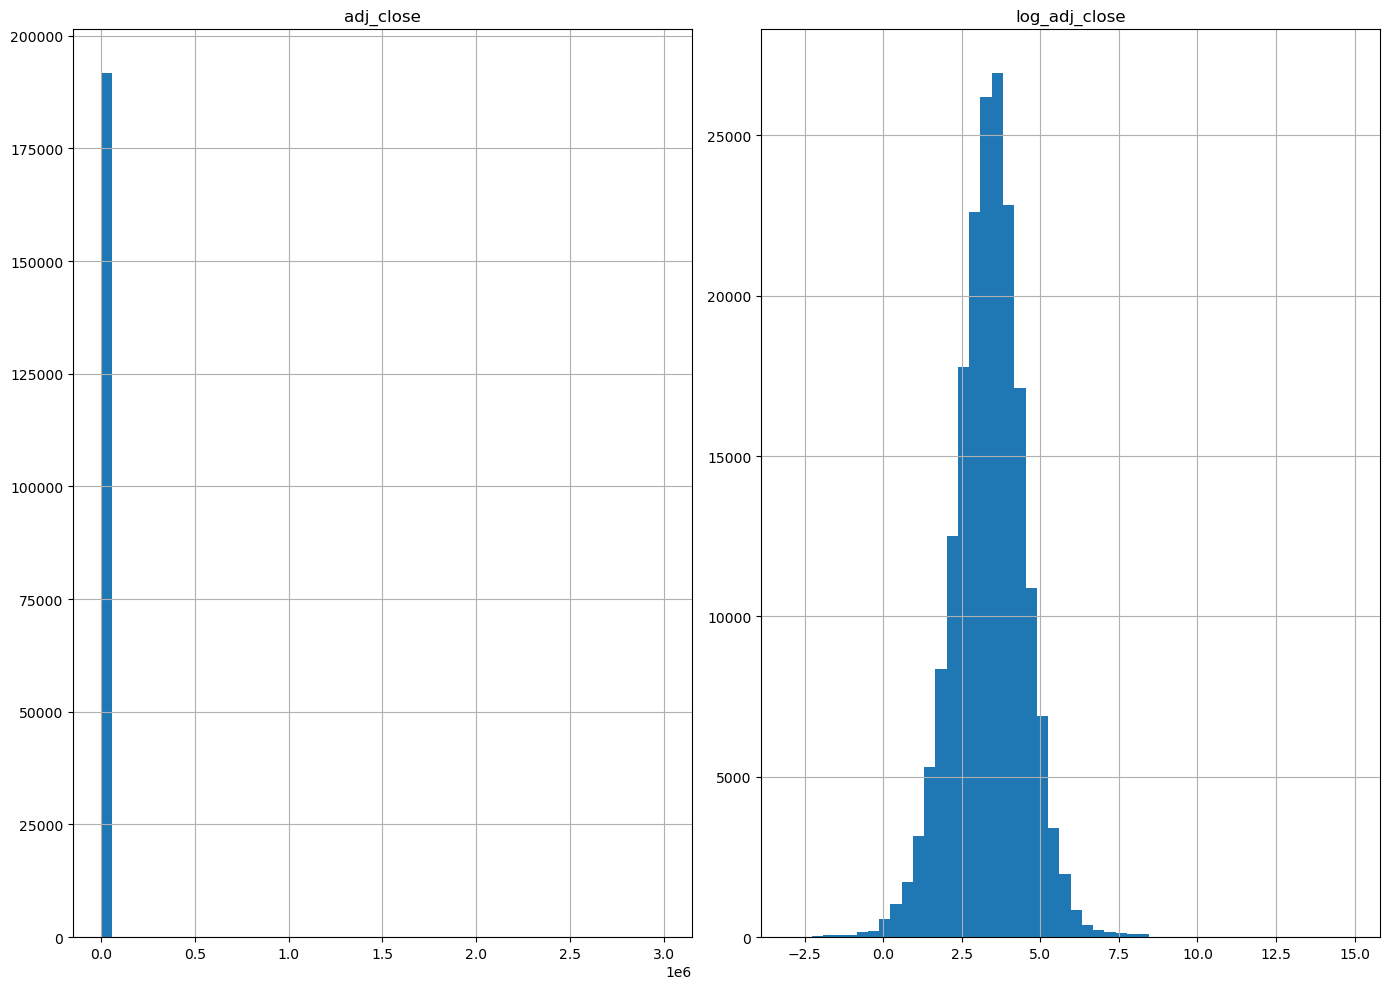

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,log_adj_close
13389,2011-01-31,NVDA,5.4642,5.2949,4.7159,0.5440,-0.8415,5.2949,4.7159,0.5440,1.3468,1.0667,0.5788,0.5941,4.3610,0.5483,-0.2287,-0.1639,-0.600933
13390,2011-01-31,GOOGL,-0.0624,-0.8036,0.0526,-0.5098,-0.5230,-0.8036,0.0526,-0.5098,-0.4942,-0.2598,0.2036,0.3742,-0.0771,14.9114,-0.1585,-0.0937,2.702126
13391,2011-01-31,AAPL,0.3574,0.0952,0.3287,1.0753,0.9573,0.0952,0.3287,1.0753,-0.5063,-0.5523,0.5788,0.5941,0.3850,10.1670,-0.0330,0.0319,2.319147
13392,2011-01-31,MSFT,-0.2377,-0.3945,-0.4650,-0.8308,-0.8139,-0.3945,-0.4650,-0.8308,-0.5135,-0.6052,0.4674,-0.1891,-0.4728,21.1071,-0.1246,-0.0597,3.049609
13393,2011-01-31,AMZN,-0.7583,-0.5117,0.7386,0.0399,0.3103,-0.5117,0.7386,0.0399,0.1250,0.0825,-0.4147,0.0118,0.0918,8.4820,0.0894,0.1543,2.137946


In [14]:
train = preprocess_data(training_data)
train.head(5)

Missing fwd_excess values:
---  ---  ---
Length of original: 45303
Length of dropped: 44391
Sanity check - missing fwd_excess values after dropping:
              Date Ticker  fwd_excess
256714  2024-03-31   ESTC      0.0926
256715  2024-03-31   CTRE     -0.0017
256716  2024-03-31   HLNE      0.0567
256717  2024-03-31    LNC     -0.0554
256718  2024-03-31   PCTY     -0.2766


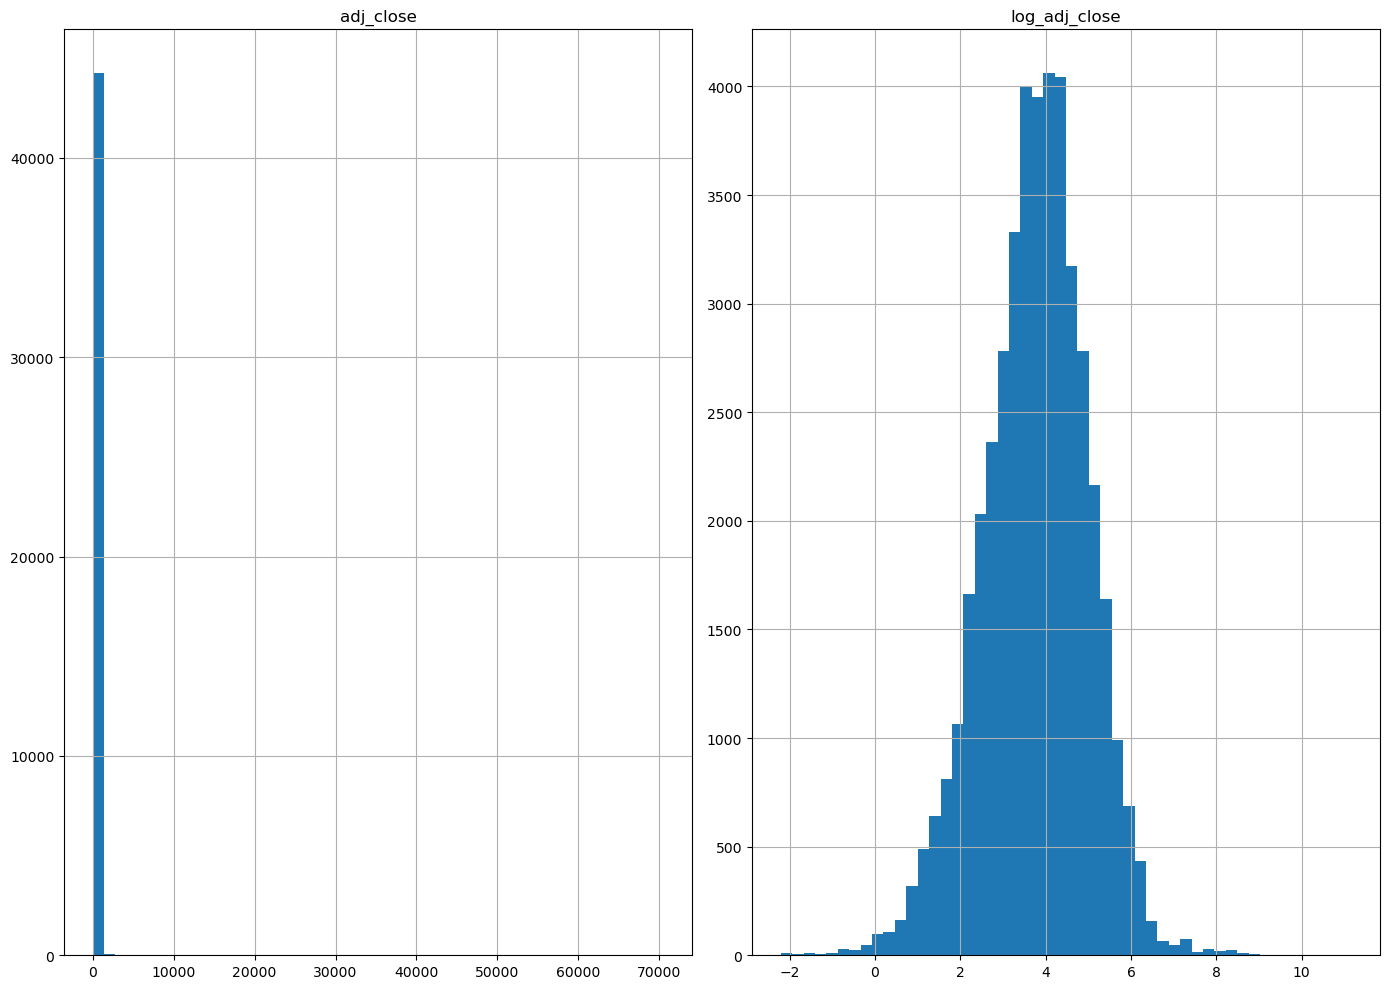

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,log_adj_close
211416,2022-02-28,MGRC,0.5220,0.3497,0.7899,-0.1215,-0.2858,0.3497,0.7899,-0.1215,-0.5288,-0.5867,0.9132,0.7814,0.5055,75.4568,0.0684,0.0170,4.323560
211418,2022-02-28,UPWK,-0.6746,-1.5168,-1.6285,-1.5480,-1.6280,-1.5168,-1.6285,-1.5480,0.9676,0.9948,-2.2430,-2.3535,-2.0995,25.2800,-0.2267,-0.2781,3.230014
211419,2022-02-28,HCM,-0.0554,-0.8946,-1.1952,-0.4110,-0.4354,-0.8946,-1.1952,-0.4110,0.7615,0.6817,-0.8278,-1.0867,-0.8628,27.2500,-0.5626,-0.6139,3.305054
211420,2022-02-28,CVBF,0.5554,1.2706,0.7908,0.0427,-0.1215,1.2706,0.7908,0.0427,-0.8153,-0.7167,0.9132,0.9933,0.9024,19.9853,0.1104,0.0591,2.994997
211421,2022-02-28,GT,-2.2646,-1.0647,-0.0001,-0.4744,0.3329,-1.0647,-0.0001,-0.4744,1.1983,1.0601,-0.9489,-0.6228,-0.8205,15.4900,-0.1146,-0.1659,2.740195


In [15]:
test = preprocess_data(testing_data)
test.head(5)

Missing fwd_excess values:
---  ---  ---
Length of original: 45305
Length of dropped: 38292
Sanity check - missing fwd_excess values after dropping:
              Date Ticker  fwd_excess
296046  2025-11-30    NZF      0.0318
296048  2025-11-30  DRSHF      0.5993
296049  2025-11-30  TSCFY     -0.0088
296050  2025-11-30   BBUC     -0.0194
296051  2025-11-30   RXRX     -0.2463


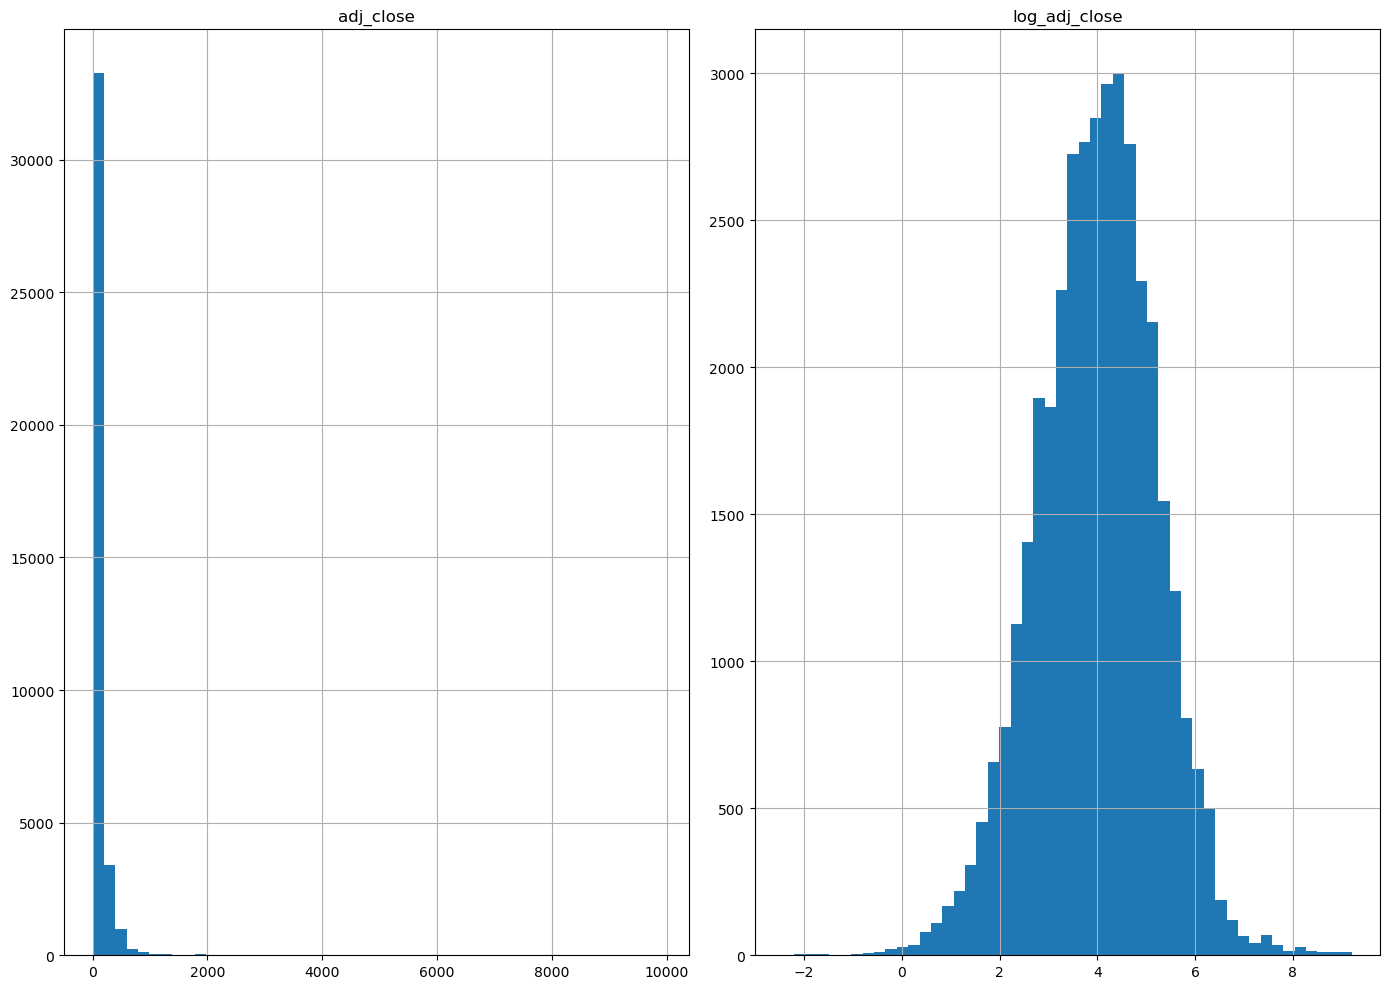

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,log_adj_close
256719,2024-03-31,BRKR,0.3159,0.7181,0.5523,-0.1805,-0.2616,0.7181,0.5523,-0.1805,-0.1594,-0.1664,0.5299,0.6222,0.8533,93.2540,-0.3640,-0.3202,4.535327
256720,2024-03-31,AEIS,-0.3499,-0.5574,-0.5785,-0.4153,-0.3718,-0.5574,-0.5785,-0.4153,-0.1198,-0.0753,-0.1813,-0.7448,-0.6970,101.4205,0.0237,0.0675,4.619275
256721,2024-03-31,AM,0.0056,0.2098,-0.0851,0.2165,0.2207,0.2098,-0.0851,0.2165,-0.4965,-0.5441,0.5299,0.6222,0.1371,12.5734,0.0217,0.0655,2.531583
256722,2024-03-31,DOCS,-0.8160,-0.4735,0.0255,-0.7497,-0.6561,-0.4735,0.0255,-0.7497,-0.0096,0.1511,0.0004,-1.3786,-0.6067,26.9100,-0.0044,0.0394,3.292498
256723,2024-03-31,MOS,0.0015,-0.6416,-0.7261,-0.9166,-0.9683,-0.6416,-0.7261,-0.9166,-0.2349,-0.1559,-0.4369,-1.0548,-0.9171,30.7564,-0.1470,-0.1032,3.426098


In [16]:
val = preprocess_data(validation_data)
val.head(5)